# Case-06：二層剛架 + 側移 (Two-Story Sway Frame)

本版直接從 GitHub 抓取最新的 `sd_framework.py` / `samples/model_two_story_sway.py`。

## 題目摘要
| 項目 | 內容 |
|---|---|
| H1 | 4.0 m |
| H2 | 3.5 m |
| L | 6.0 m |
| P1 | 15.0 kN |
| P2 | 10.0 kN |
| Dk | 6 (θ_B, θ_C, θ_D, θ_E, ψ1, ψ2) |

## 0. 安裝套件 + 抓取最新原始碼

In [1]:
try:
    import anastruct
    print("已偵測到 anastruct，略過安裝")
except ImportError:
    print("未偵測到 anastruct，開始安裝...")
    !pip install anastruct -q --break-system-packages
    try:
        import anastruct
        print("安裝完成，可以繼續往下執行")
    except ImportError:
        print("安裝後仍無法載入，這是 Colab 偶爾會發生的快取問題，"
              "請直接重新執行這個 cell 一次（通常第二次就會成功）")

%matplotlib inline

已偵測到 anastruct，略過安裝


In [2]:
import sys
for _m in ['sd_framework', 'model_two_story_sway']:
    if _m in sys.modules:
        del sys.modules[_m]

!wget -q -O sd_framework.py https://raw.githubusercontent.com/zhixiu0223/slope_deflection_framework/main/sd_framework.py
!wget -q -O model_two_story_sway.py https://raw.githubusercontent.com/zhixiu0223/slope_deflection_framework/main/samples/model_two_story_sway.py

from sd_framework import SlopeDeflectionSolver, member_shear_curve, member_moment_curve, member_offset_curve
from model_two_story_sway import TwoStorySwayFrameProblem
print("原始碼抓取完成")

原始碼抓取完成


## 1. 求解並產生「手寫詳解」風格輸出（步驟1~5）


【步驟 1】題目定義、幾何/材料參數與自由度標示


**① 結構定義、幾何與邊界條件**

**一樓層高** $H_1=4.0$ m，**二樓層高** $H_2=3.5$ m，**跨度** $L=6.0$ m

**一樓樓板水平力** $P_1=15.0$ kN，**屋頂水平力** $P_2=10.0$ kN

**邊界條件：** A、F兩端固定 ($\theta_A=\theta_F=0$)

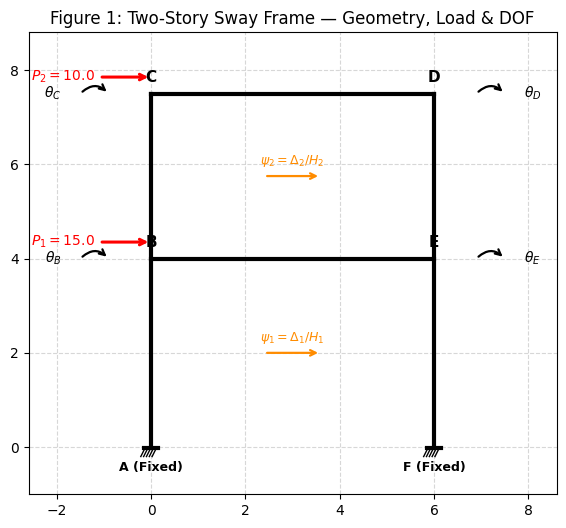

**② ⚠️ 自由度選取**（這一步選錯或漏掉，後面所有方程式都會建立在錯誤基礎上、整題全錯，是最需要覆核的一步）：

水平力 P1、P2 讓構架側移，而且**兩層樓的側移量不一定相同**——不能只用一個共用的側移角(那是單層剛架Case-04的做法)，二層樓要各自設一個側移角：$\psi_1=\Delta_1/H_1$(一樓層間側移角)、$\psi_2=\Delta_2/H_2$(二樓層間側移角，$\Delta_2$ 是C、D相對於B、E的相對側移量，不是C、D的絕對側移)。加上四個節點轉角 $\theta_B,\theta_C,\theta_D,\theta_E$，共 **6個未知位移量**——這是本Case的關鍵、也是跟Case-04(只有1個ψ)、Case-05(4個轉角但無側移)最大的差異：兩者的特性這裡同時出現。

對應**六條方程式**：四個節點力矩平衡(ΣM_B=ΣM_C=ΣM_D=ΣM_E=0) + 兩條樓層剪力平衡(每一層樓的柱子剪力總和要跟該層樓「以上」所有水平力平衡)。


【步驟 2】寫出桿端彎矩方程式


**① 公式引用**（傾角變位法一般式，對任何桿件 i→j 都適用，跟結構種類無關）：

$$M_{ij} = \frac{2EI}{L}\left(2\theta_i + \theta_j - 3\psi\right) + FEM_{ij}$$

其中 $\theta_i,\theta_j$ 為兩端轉角，$\psi=\Delta/L$ 為側移角（無側移時 $\psi=0$），$FEM_{ij}$ 為固定端彎矩(依載重種類查表)。

**② 代入本題的邊界條件、跨長與載重**，得到每根桿件的具體算式：


【步驟 3】建立平衡方程式


**平衡方程式**（每條方程式對應哪個節點/桿件、哪一種平衡條件）：

- 節點 B 力矩平衡 ΣM_B=0 M_BA+M_BC+M_BE=0

- 節點 C 力矩平衡 ΣM_C=0 M_CB+M_CD=0

- 節點 D 力矩平衡 ΣM_D=0 M_DC+M_DE=0

- 節點 E 力矩平衡 ΣM_E=0 M_EF+M_ED+M_EB=0

- 一樓層剪力平衡（一樓以上所有水平力P1+P2要跟一樓兩柱剪力平衡） (M_AB+M_BA)/H1+(M_FE+M_EF)/H1+P1+P2=0

- 二樓層剪力平衡（只有屋頂P2在二樓層之上） (M_BC+M_CB)/H2+(M_ED+M_DE)/H2+P2=0


【步驟 4】求解聯立方程式 (未知位移量)


**① 符號解**（保留 EI 符號，這是傾角變位法教學上的標準步驟——對單一材料/均勻EI的靜不定結構，解出來的桿端彎矩最終會跟EI無關，所以先看符號解能清楚看出這個特性）：

**② 代入 EI 數值**（EI = 15000.0，方便直接跟 anastruct、OpenSeesPy 這類數值工具的結果對照，不用自己心算分數/小數）：


【步驟 5】計算真實桿端彎矩與反力


**最終桿端彎矩計算結果 (kN·m)：**

M_{AB} = -31.061 kN·m
M_{BA} = -18.939 kN·m
M_{FE} = -31.061 kN·m
M_{EF} = -18.939 kN·m
M_{BC} = -5.307 kN·m
M_{CB} = -12.193 kN·m
M_{ED} = -5.307 kN·m
M_{DE} = -12.193 kN·m
M_{BE} = 24.245 kN·m
M_{EB} = 24.245 kN·m
M_{CD} = 12.193 kN·m
M_{DC} = 12.193 kN·m

-> H_A (kN) = -12.500
-> H_F (kN) = -12.500


{'moments': {'M_{AB}': -31.06132075471698,
  'M_{BA}': -18.93867924528302,
  'M_{FE}': -31.06132075471698,
  'M_{EF}': -18.93867924528302,
  'M_{BC}': -5.306603773584913,
  'M_{CB}': -12.1933962264151,
  'M_{ED}': -5.3066037735849125,
  'M_{DE}': -12.193396226415098,
  'M_{BE}': 24.245283018867923,
  'M_{EB}': 24.245283018867923,
  'M_{CD}': 12.193396226415093,
  'M_{DC}': 12.193396226415093},
 'reactions': {'H_A (kN)': -12.5, 'H_F (kN)': -12.5},
 'solution': {psi1: 28.7893081761006/EI,
  psi2: 23.3235062893082/EI,
  theta_B: 24.2452830188679/EI,
  theta_C: 12.1933962264151/EI,
  theta_D: 12.1933962264151/EI,
  theta_E: 24.2452830188679/EI}}

In [3]:
problem = TwoStorySwayFrameProblem(H1=4.0, H2=3.5, L=6.0, P1=15.0, P2=10.0, EI_numeric=15000.0)
solver = SlopeDeflectionSolver(problem)
solver.solve_and_report()

## 1b. 教學講義輸出（只有五張圖）

### a. 結構受力圖

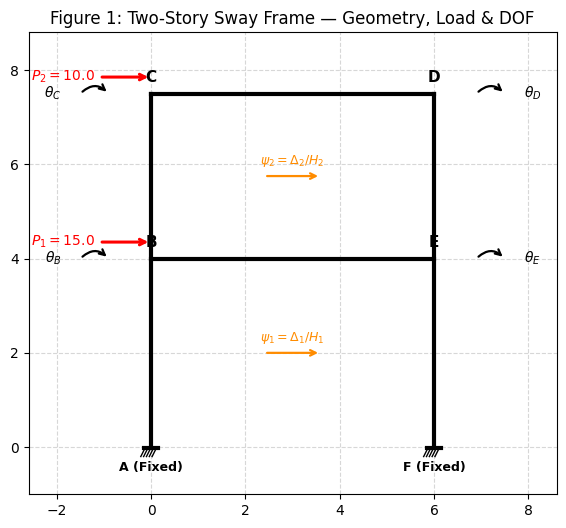

### b. 剪力圖 (SFD)

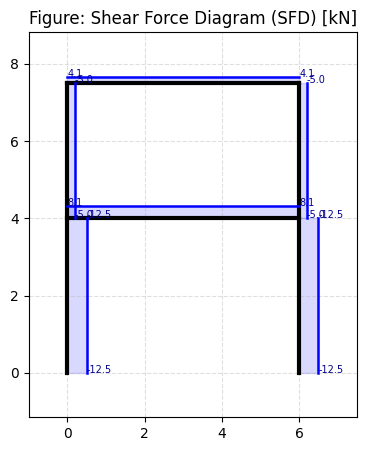

### c. 彎矩圖 (BMD)

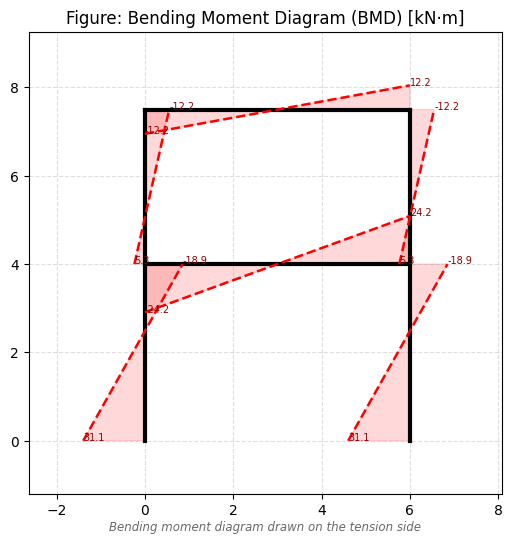

### d. 拉力側標註圖

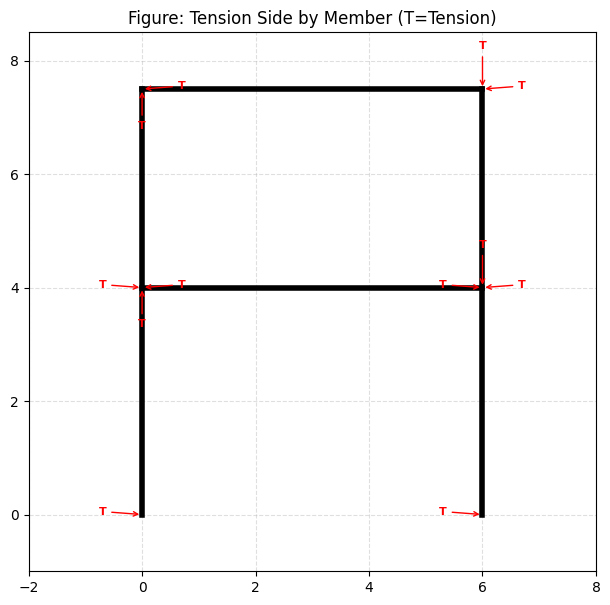

### e. 變形圖

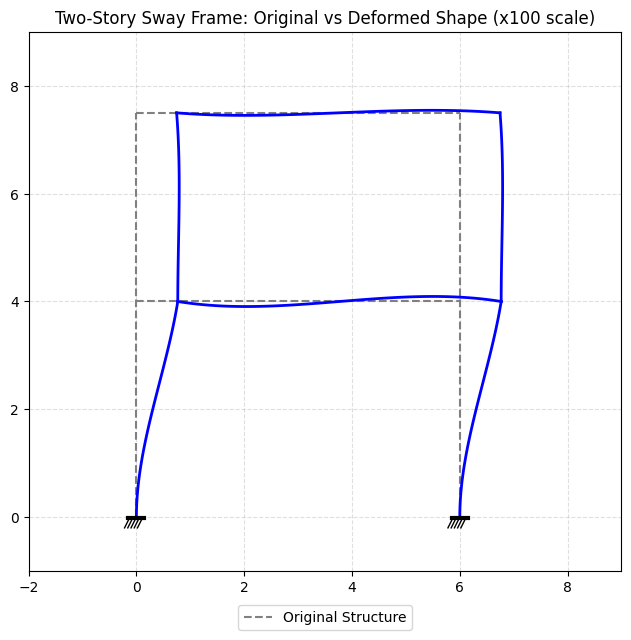

In [4]:
solver.print_teaching_handout()

## 2. anastruct 獨立建模驗證

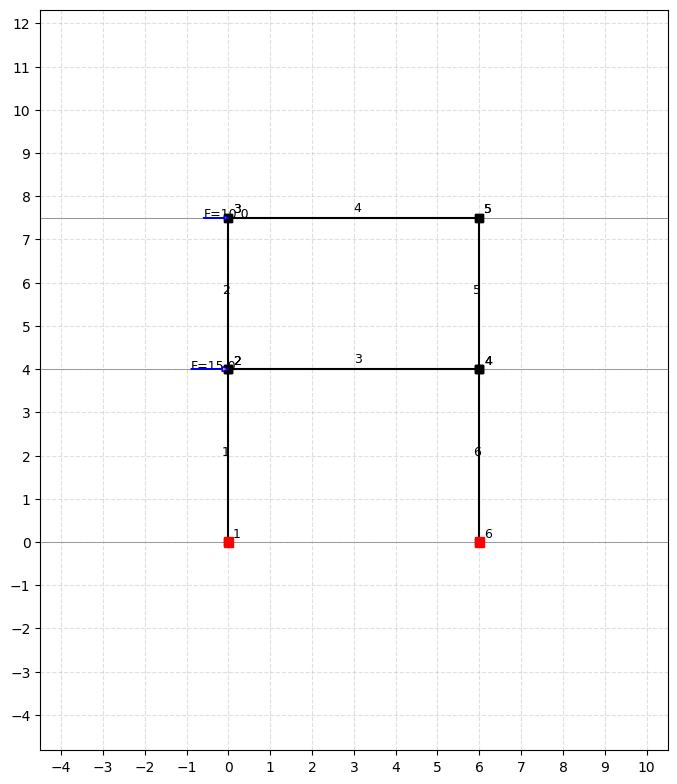

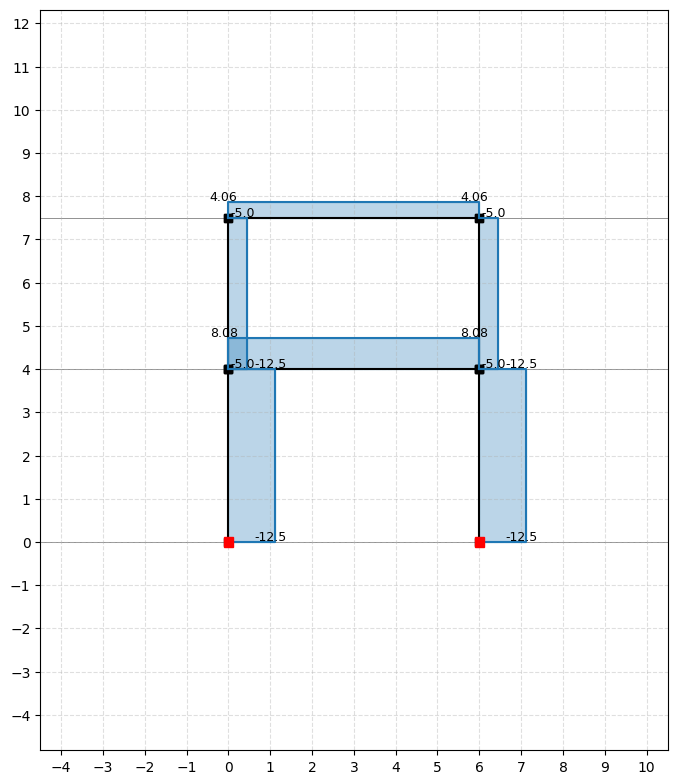

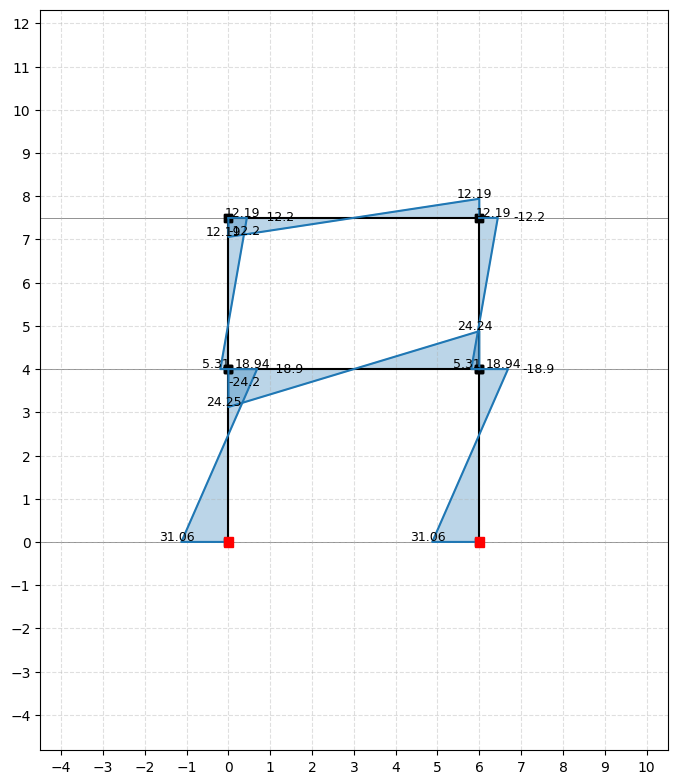

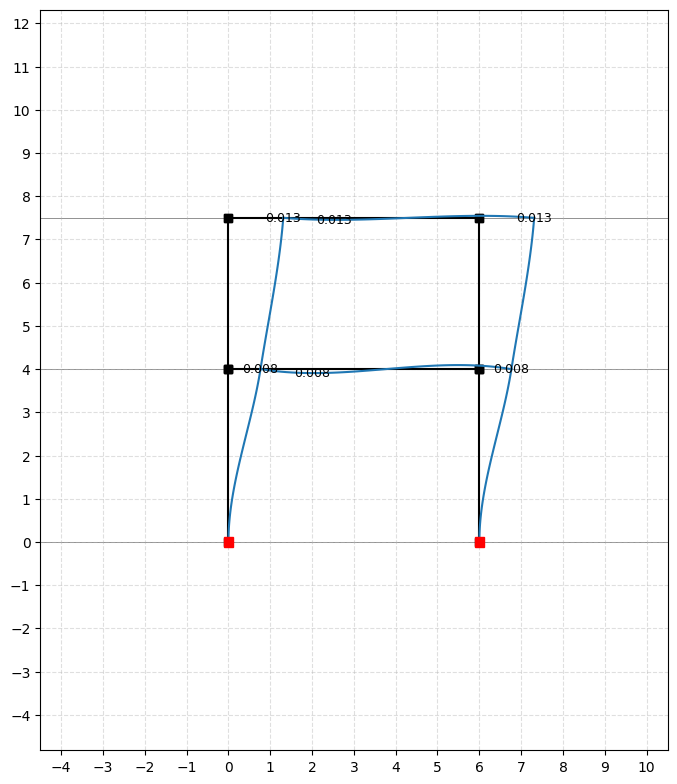

柱AB: A=31.063 B=18.939
柱BC: B=5.306 C=12.193
梁BE: B=-24.245 E=-24.245
梁CD: C=-12.193 D=-12.193
柱ED: E=5.308 D=12.193
柱FE: F=31.061 E=18.937


In [5]:
from anastruct import SystemElements
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

H1, H2, L, P1, P2 = 4.0, 3.5, 6.0, 15.0, 10.0
Htot = H1 + H2
ss = SystemElements(EA=1e8, EI=15000.0)
ss.add_element(location=[[0, 0], [0, H1]])
ss.add_element(location=[[0, H1], [0, Htot]])
ss.add_element(location=[[0, H1], [L, H1]])
ss.add_element(location=[[0, Htot], [L, Htot]])
ss.add_element(location=[[L, H1], [L, Htot]])
ss.add_element(location=[[L, 0], [L, H1]])
ss.add_support_fixed(node_id=1)
ss.add_support_fixed(node_id=6)
ss.point_load(node_id=2, Fx=P1)
ss.point_load(node_id=3, Fx=P2)
ss.solve()

def apply_grid(fig, y_lines=()):
    ax = fig.axes[0]
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(mticker.MultipleLocator(1))
    ax.grid(True, linestyle='--', alpha=0.4)
    for y in y_lines:
        ax.axhline(y, color='gray', lw=0.6, zorder=0)
    return fig

fig_s = ss.show_structure(show=False, figsize=(7, 8))
apply_grid(fig_s, [0, H1, Htot])
plt.show()

fig_v = ss.show_shear_force(show=False, figsize=(7, 8))
apply_grid(fig_v, [0, H1, Htot])
plt.show()

fig_m = ss.show_bending_moment(show=False, figsize=(7, 8))
apply_grid(fig_m, [0, H1, Htot])
plt.show()

fig_d = ss.show_displacement(show=False, factor=100, figsize=(7, 8))
apply_grid(fig_d, [0, H1, Htot])
plt.show()

el1,el2,el3,el4,el5,el6 = [ss.element_map[i] for i in range(1,7)]
print("柱AB: A=%.3f B=%.3f" % (el1.node_1.Tz, el1.node_2.Tz))
print("柱BC: B=%.3f C=%.3f" % (el2.node_1.Tz, el2.node_2.Tz))
print("梁BE: B=%.3f E=%.3f" % (el3.node_1.Tz, el3.node_2.Tz))
print("梁CD: C=%.3f D=%.3f" % (el4.node_1.Tz, el4.node_2.Tz))
print("柱ED: E=%.3f D=%.3f" % (el5.node_1.Tz, el5.node_2.Tz))
print("柱FE: F=%.3f E=%.3f" % (el6.node_1.Tz, el6.node_2.Tz))

## 3. 彎矩交叉檢查

In [6]:
ours = {'AB':(-31.061,-18.939), 'BC':(-5.307,-12.193), 'BE':(24.245,24.245),
        'CD':(12.193,12.193), 'ED':(-5.307,-12.193), 'FE':(-31.061,-18.939)}
anastruct_raw = {'AB':(el1.node_1.Tz, el1.node_2.Tz), 'BC':(el2.node_1.Tz, el2.node_2.Tz),
                  'BE':(el3.node_1.Tz, el3.node_2.Tz), 'CD':(el4.node_1.Tz, el4.node_2.Tz),
                  'ED':(el5.node_1.Tz, el5.node_2.Tz), 'FE':(el6.node_1.Tz, el6.node_2.Tz)}
all_ok = True
for name in ours:
    o1, o2 = ours[name]
    a1, a2 = anastruct_raw[name]
    ok = abs(o1 - (-a1)) < 0.05 and abs(o2 - (-a2)) < 0.05
    all_ok = all_ok and ok
    print(f"{name}: {'✓' if ok else '✗'}")
assert all_ok
print("\n彎矩交叉檢查通過 ✓")

AB: ✓
BC: ✓
BE: ✓
CD: ✓
ED: ✓
FE: ✓

彎矩交叉檢查通過 ✓
